# 3.7 Dimension-Factor Correlation Analysis

This notebook identifies which latent dimensions are most strongly correlated with specific factors:
- **Age**: Continuous variable
- **Sex**: Binary variable (0=Female, 1=Male)
- **Handedness**: Categorical variable (1=Right, 2=Left)
- **Scanner**: Categorical variable (Manufacturer)
- **SBR**: Continuous variable (using SBR_PC1 as primary pathology measure)

## Objective
For each factor, identify:
1. The **single dimension** with the highest correlation
2. The **separation gap** between the top dimension and the 2nd-best dimension
3. Whether this top dimension is well-separated (indicating a clear signal)

## Methods
- **Pearson correlation**: For continuous variables (Age, SBR_PC1)
- **Point-biserial correlation**: For binary variables (Sex)
- **Eta-squared (η²)**: For categorical variables (Handedness, Scanner)
- **Separation metric**: Gap between 1st and 2nd ranked correlations

## Section 1: Setup and Data Loading

### 1.1 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from scipy import stats
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Define Constants

In [3]:
FEATURE_COLS = [f'latent_{i}' for i in range(256)]
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

RANDOM_STATE = 42

print(f"Number of latent dimensions: {len(FEATURE_COLS)}")

Number of latent dimensions: 256


### 1.3 Load and Merge All Data

In [6]:
# Load merged clinical data
df_merged = pd.read_csv('output/merged_data.csv')
print(f"Merged clinical data: {df_merged.shape}")

# Load latent vectors
latent_file = 'output/Experiments/LatentVectorAnalysis/train_latent_vectors_with_patno.csv'
df_latent = pd.read_csv(latent_file)
print(f"Latent vectors: {df_latent.shape}")

# Load DICOM metadata for scanner info
df_dicom = pd.read_csv('data/csvData/dicom_metadata.csv')
print(f"DICOM metadata: {df_dicom.shape}")

# Extract PATNO from DICOM file paths
def extract_patno_from_dicom_path(file_path):
    match = re.search(r'PPMI_Images_[^\\]+\\(\d+)', str(file_path))
    if match:
        return int(match.group(1))
    return None

df_dicom['PATNO'] = df_dicom['file_path'].apply(extract_patno_from_dicom_path)
df_dicom_latest = df_dicom.sort_values('file_path').drop_duplicates('PATNO', keep='last')

# Merge latent with clinical data
df_latent_clean = df_latent.dropna(subset=['PATNO']).copy()
df_combined = pd.merge(df_latent_clean, df_merged, on='PATNO', how='inner')
print(f"\nCombined latent + clinical: {df_combined.shape}")

# Merge with scanner info
df_combined = pd.merge(
    df_combined, 
    df_dicom_latest[['PATNO', 'Manufacturer', 'ManufacturerModelName']], 
    on='PATNO', 
    how='right'
)
print(f"Combined with scanner info: {df_combined.shape}")

Merged clinical data: (41816, 42)
Latent vectors: (2340, 260)
DICOM metadata: (2986, 6)

Combined latent + clinical: (34936, 301)
Combined with scanner info: (35174, 303)


### 1.4 Calculate SBR Principal Components

In [4]:
# Filter to rows with complete SBR data
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
print(f"Rows with complete SBR data: {len(df_with_sbr)}")

# Standardize and apply PCA
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=RANDOM_STATE)
sbr_pcs = pca.fit_transform(sbr_scaled)

df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nSBR PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Use this as final dataset
df_final = df_with_sbr.reset_index(drop=True)
print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Rows with complete SBR data: 6630

SBR PCA explained variance: [0.84380623 0.07906205 0.05842364]
Total variance explained: 98.13%

Final dataset: (6630, 306)
Unique patients: 1406


### 1.5 Check Available Factors

In [6]:
print("Factor Availability Check:")
print("="*80)

# Age
age_available = df_final['AGE_AT_VISIT'].notna().sum()
print(f"\nAge (AGE_AT_VISIT):")
print(f"  Available: {age_available}/{len(df_final)} ({age_available/len(df_final)*100:.1f}%)")
if age_available > 0:
    print(f"  Range: [{df_final['AGE_AT_VISIT'].min():.0f}, {df_final['AGE_AT_VISIT'].max():.0f}]")
    print(f"  Mean: {df_final['AGE_AT_VISIT'].mean():.1f}")

# Sex
sex_available = df_final['SEX'].notna().sum()
print(f"\nSex:")
print(f"  Available: {sex_available}/{len(df_final)} ({sex_available/len(df_final)*100:.1f}%)")
if sex_available > 0:
    print(f"  Distribution:\n{df_final['SEX'].value_counts()}")

# Handedness
handed_available = df_final['HANDED'].notna().sum()
print(f"\nHandedness:")
print(f"  Available: {handed_available}/{len(df_final)} ({handed_available/len(df_final)*100:.1f}%)")
if handed_available > 0:
    print(f"  Distribution:\n{df_final['HANDED'].value_counts()}")


# Scanner
scanner_available = df_final['Manufacturer'].notna().sum()
print(f"\nScanner (Manufacturer):")
print(f"  Available: {scanner_available}/{len(df_final)} ({scanner_available/len(df_final)*100:.1f}%)")
if scanner_available > 0:
    print(f"  Unique manufacturers: {df_final['Manufacturer'].nunique()}")
    print(f"  Top 5:\n{df_final['Manufacturer'].value_counts().head()}")

# SBR
sbr_available = df_final['SBR_PC1'].notna().sum()
print(f"\nSBR (SBR_PC1):")
print(f"  Available: {sbr_available}/{len(df_final)} ({sbr_available/len(df_final)*100:.1f}%)")
if sbr_available > 0:
    print(f"  Range: [{df_final['SBR_PC1'].min():.2f}, {df_final['SBR_PC1'].max():.2f}]")
    print(f"  Mean: {df_final['SBR_PC1'].mean():.2f}")

Factor Availability Check:

Age (AGE_AT_VISIT):
  Available: 6629/6630 (100.0%)
  Range: [31, 89]
  Mean: 63.6

Sex:
  Available: 6629/6630 (100.0%)
  Distribution:
SEX
1.0    4198
0.0    2431
Name: count, dtype: int64

Handedness:
  Available: 6626/6630 (99.9%)
  Distribution:
HANDED
1.0    5770
2.0     647
3.0     209
Name: count, dtype: int64

Scanner (Manufacturer):
  Available: 6629/6630 (100.0%)
  Unique manufacturers: 15
  Top 5:
Manufacturer
SIEMENS NM                              3258
GE MEDICAL SYSTEMS                      1335
Marconi Medical Systems, NM Division     840
Philips Nuclear Medicine                 383
PICKER                                   233
Name: count, dtype: int64

SBR (SBR_PC1):
  Available: 6630/6630 (100.0%)
  Range: [-4.93, 14.24]
  Mean: 0.00


## Section 2: Correlation Analysis Functions

### 2.1 Define Correlation Functions

In [7]:
def compute_continuous_correlations(X, y, feature_names):
    """
    Compute Pearson correlations between features (X) and continuous target (y).
    Returns DataFrame with correlations, p-values, and absolute correlations.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | np.isnan(y))
        if mask.sum() < 3:
            continue
            
        r, p = stats.pearsonr(X[mask, i], y[mask])
        results.append({
            'Feature': feature,
            'Correlation': r,
            'P_Value': p,
            'Abs_Correlation': abs(r)
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


def compute_binary_correlations(X, y, feature_names):
    """
    Compute point-biserial correlations between features (X) and binary target (y).
    Returns DataFrame with correlations, p-values, and absolute correlations.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | np.isnan(y))
        if mask.sum() < 3:
            continue
            
        r, p = pointbiserialr(y[mask], X[mask, i])
        results.append({
            'Feature': feature,
            'Correlation': r,
            'P_Value': p,
            'Abs_Correlation': abs(r)
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


def compute_categorical_associations(X, y, feature_names):
    """
    Compute eta-squared (η²) for association between features (X) and categorical target (y).
    η² represents the proportion of variance in the feature explained by the category.
    Returns DataFrame with eta-squared values.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | pd.isna(y))
        if mask.sum() < 3:
            continue
        
        x_clean = X[mask, i]
        y_clean = y[mask]
        
        # Get unique categories
        categories = np.unique(y_clean)
        if len(categories) < 2:
            continue
        
        # Compute ANOVA
        groups = [x_clean[y_clean == cat] for cat in categories]
        f_stat, p_val = stats.f_oneway(*groups)
        
        # Compute eta-squared
        grand_mean = x_clean.mean()
        ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
        ss_total = sum((x_clean - grand_mean)**2)
        eta_squared = ss_between / ss_total if ss_total > 0 else 0
        
        results.append({
            'Feature': feature,
            'Eta_Squared': eta_squared,
            'F_Statistic': f_stat,
            'P_Value': p_val
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Eta_Squared', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


print("Correlation functions defined successfully!")

Correlation functions defined successfully!


### 2.2 Define Separation Analysis Function

In [8]:
def analyze_separation(df_corr, metric_col='Abs_Correlation', top_n=10):
    """
    Analyze separation between top-ranked features.
    Returns summary statistics and separation gap.
    """
    if len(df_corr) < 2:
        return None
    
    top_feature = df_corr.iloc[0]
    second_feature = df_corr.iloc[1]
    
    gap = top_feature[metric_col] - second_feature[metric_col]
    gap_pct = (gap / top_feature[metric_col] * 100) if top_feature[metric_col] > 0 else 0
    
    summary = {
        'Top_Feature': top_feature['Feature'],
        'Top_Value': top_feature[metric_col],
        'Second_Feature': second_feature['Feature'],
        'Second_Value': second_feature[metric_col],
        'Gap': gap,
        'Gap_Percent': gap_pct,
        'Top_N_Features': df_corr.head(top_n)['Feature'].tolist(),
        'Top_N_Values': df_corr.head(top_n)[metric_col].tolist()
    }
    
    return summary


print("Separation analysis function defined!")

Separation analysis function defined!


## Section 3: Factor-by-Factor Analysis

### 3.1 Extract Latent Features

In [9]:
# Extract latent features matrix
X_latent = df_final[FEATURE_COLS].values
print(f"Latent features matrix shape: {X_latent.shape}")
print(f"Missing values: {np.isnan(X_latent).sum()}")

Latent features matrix shape: (6630, 256)
Missing values: 0


### 3.2 Age Analysis

In [10]:
print("="*80)
print("FACTOR 1: AGE")
print("="*80)

y_age = df_final['AGE_AT_VISIT'].values
print(f"\nSamples with valid age: {(~np.isnan(y_age)).sum()}")

# Compute correlations
df_age_corr = compute_continuous_correlations(X_latent, y_age, FEATURE_COLS)

# Analyze separation
age_sep = analyze_separation(df_age_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {age_sep['Top_Feature']}")
print(f"  Correlation: {age_sep['Top_Value']:.4f}")
print(f"  P-value: {df_age_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {age_sep['Second_Feature']}")
print(f"  Correlation: {age_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {age_sep['Gap']:.4f}")
print(f"  Relative: {age_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_age_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))

FACTOR 1: AGE

Samples with valid age: 6629

Top dimension: latent_189
  Correlation: 0.4159
  P-value: 1.3357e-275

Second-best dimension: latent_208
  Correlation: 0.3202

Separation Gap:
  Absolute: 0.0957
  Relative: 23.0%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation       P_Value
    1 latent_189    -0.415864         0.415864 1.335675e-275
    2 latent_208    -0.320203         0.320203 6.560051e-158
    3 latent_130     0.281425         0.281425 6.357162e-121
    4 latent_136    -0.273163         0.273163 9.100063e-114
    5  latent_80    -0.263678         0.263678 7.429109e-106
    6 latent_249     0.262406         0.262406 8.081296e-105
    7 latent_203    -0.245172         0.245172  2.468676e-91
    8 latent_176     0.238095         0.238095  4.287687e-86
    9 latent_110     0.229028         0.229028  1.245302e-79
   10  latent_92     0.227140         0.227140  2.549599e-78


### 3.3 Sex Analysis

In [11]:
print("\n" + "="*80)
print("FACTOR 2: SEX")
print("="*80)

y_sex = df_final['SEX'].values
print(f"\nSamples with valid sex: {(~np.isnan(y_sex)).sum()}")
print(f"Distribution: Female={(y_sex==0).sum()}, Male={(y_sex==1).sum()}")

# Compute correlations
df_sex_corr = compute_binary_correlations(X_latent, y_sex, FEATURE_COLS)

# Analyze separation
sex_sep = analyze_separation(df_sex_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {sex_sep['Top_Feature']}")
print(f"  Correlation: {sex_sep['Top_Value']:.4f}")
print(f"  P-value: {df_sex_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {sex_sep['Second_Feature']}")
print(f"  Correlation: {sex_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {sex_sep['Gap']:.4f}")
print(f"  Relative: {sex_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_sex_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))


FACTOR 2: SEX

Samples with valid sex: 6629
Distribution: Female=2431, Male=4198

Top dimension: latent_189
  Correlation: 0.2430
  P-value: 1.1306e-89

Second-best dimension: latent_208
  Correlation: 0.2385

Separation Gap:
  Absolute: 0.0045
  Relative: 1.9%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation      P_Value
    1 latent_189    -0.242954         0.242954 1.130575e-89
    2 latent_208    -0.238456         0.238456 2.336763e-86
    3 latent_191     0.217547         0.217547 7.648597e-72
    4  latent_48    -0.217250         0.217250 1.198975e-71
    5  latent_92     0.215065         0.215065 3.229082e-70
    6  latent_71     0.208592         0.208592 4.511133e-66
    7  latent_44    -0.207373         0.207373 2.627567e-65
    8 latent_152     0.204517         0.204517 1.561283e-63
    9 latent_176     0.197266         0.197266 3.781184e-59
   10 latent_141    -0.183655         0.183655 2.241969e-51


### 3.4 Handedness Analysis

In [12]:
print("\n" + "="*80)
print("FACTOR 3: HANDEDNESS")
print("="*80)

y_hand = df_final["HANDED"].values
valid_hand = pd.notna(y_hand)
print(f"\nSamples with valid handedness: {valid_hand.sum()}")

if valid_hand.sum() > 0:
    print(f"Distribution:\n{pd.Series(y_hand).value_counts()}")
    
    # Categorical - use eta-squared
    print("\nTreating as categorical variable...")
    df_hand_corr = compute_categorical_associations(X_latent, y_hand, FEATURE_COLS)
    metric_col = 'Eta_Squared'
    
    # Analyze separation
    hand_sep = analyze_separation(df_hand_corr, metric_col=metric_col, top_n=10)
    
    print(f"\nTop dimension: {hand_sep['Top_Feature']}")
    print(f"  {metric_col}: {hand_sep['Top_Value']:.4f}")
    print(f"  P-value: {df_hand_corr.iloc[0]['P_Value']:.4e}")
    
    print(f"\nSecond-best dimension: {hand_sep['Second_Feature']}")
    print(f"  {metric_col}: {hand_sep['Second_Value']:.4f}")
    
    print(f"\nSeparation Gap:")
    print(f"  Absolute: {hand_sep['Gap']:.4f}")
    print(f"  Relative: {hand_sep['Gap_Percent']:.1f}%")
    
    print(f"\nTop 10 dimensions:")
    print(df_hand_corr.head(10).to_string(index=False))


FACTOR 3: HANDEDNESS

Samples with valid handedness: 6626
Distribution:
1.0    5770
2.0     647
3.0     209
Name: count, dtype: int64

Treating as categorical variable...

Top dimension: latent_58
  Eta_Squared: 0.0161
  P-value: 3.9428e-24

Second-best dimension: latent_63
  Eta_Squared: 0.0111

Separation Gap:
  Absolute: 0.0051
  Relative: 31.3%

Top 10 dimensions:
   Feature  Eta_Squared  F_Statistic      P_Value  Rank
 latent_58     0.016142    54.331046 3.942754e-24     1
 latent_63     0.011082    37.107933 9.415762e-17     2
latent_169     0.007730    25.797270 6.915153e-12     3
 latent_96     0.006936    23.127835 9.786373e-11     4
latent_211     0.006565    21.882362 3.371883e-10     5
 latent_65     0.006091    20.293499 1.635085e-09     6
 latent_60     0.006025    20.071513 2.038750e-09     7
  latent_7     0.006016    20.042382 2.098645e-09     8
  latent_3     0.005980    19.922763 2.363617e-09     9
 latent_53     0.005897    19.644315 3.117364e-09    10


### 3.5 Scanner Analysis

In [13]:
print("\n" + "="*80)
print("FACTOR 4: SCANNER (Manufacturer)")
print("="*80)

y_scanner = df_final['Manufacturer'].values
valid_scanner = pd.notna(y_scanner)
print(f"\nSamples with valid scanner: {valid_scanner.sum()}")
print(f"Unique manufacturers: {pd.Series(y_scanner).nunique()}")
print(f"\nTop 5 manufacturers:\n{pd.Series(y_scanner).value_counts().head()}")

# Compute eta-squared
df_scanner_corr = compute_categorical_associations(X_latent, y_scanner, FEATURE_COLS)

# Analyze separation
scanner_sep = analyze_separation(df_scanner_corr, metric_col='Eta_Squared', top_n=10)

print(f"\nTop dimension: {scanner_sep['Top_Feature']}")
print(f"  Eta-squared: {scanner_sep['Top_Value']:.4f}")
print(f"  P-value: {df_scanner_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {scanner_sep['Second_Feature']}")
print(f"  Eta-squared: {scanner_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {scanner_sep['Gap']:.4f}")
print(f"  Relative: {scanner_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_scanner_corr.head(10).to_string(index=False))


FACTOR 4: SCANNER (Manufacturer)

Samples with valid scanner: 6629
Unique manufacturers: 15

Top 5 manufacturers:
SIEMENS NM                              3258
GE MEDICAL SYSTEMS                      1335
Marconi Medical Systems, NM Division     840
Philips Nuclear Medicine                 383
PICKER                                   233
Name: count, dtype: int64

Top dimension: latent_85
  Eta-squared: 0.1440
  P-value: 7.3128e-211

Second-best dimension: latent_43
  Eta-squared: 0.1286

Separation Gap:
  Absolute: 0.0155
  Relative: 10.7%

Top 10 dimensions:
   Feature  Eta_Squared  F_Statistic       P_Value  Rank
 latent_85     0.144026    79.490887 7.312773e-211     1
 latent_43     0.128565    69.698810 1.899578e-185     2
latent_196     0.124399    67.118898 1.106791e-178     3
latent_213     0.119678    64.225865 4.625420e-171     4
latent_255     0.112205    59.708432 4.349584e-159     5
 latent_31     0.110176    58.494870 7.414882e-156     6
latent_140     0.106355    56.2250

### 3.6 SBR Analysis

In [14]:
print("\n" + "="*80)
print("FACTOR 5: SBR (SBR_PC1)")
print("="*80)

y_sbr = df_final['SBR_PC1'].values
print(f"\nSamples with valid SBR: {(~np.isnan(y_sbr)).sum()}")
print(f"SBR_PC1 range: [{np.nanmin(y_sbr):.2f}, {np.nanmax(y_sbr):.2f}]")
print(f"SBR_PC1 mean: {np.nanmean(y_sbr):.2f}")

# Compute correlations
df_sbr_corr = compute_continuous_correlations(X_latent, y_sbr, FEATURE_COLS)

# Analyze separation
sbr_sep = analyze_separation(df_sbr_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {sbr_sep['Top_Feature']}")
print(f"  Correlation: {sbr_sep['Top_Value']:.4f}")
print(f"  P-value: {df_sbr_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {sbr_sep['Second_Feature']}")
print(f"  Correlation: {sbr_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {sbr_sep['Gap']:.4f}")
print(f"  Relative: {sbr_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_sbr_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))


FACTOR 5: SBR (SBR_PC1)

Samples with valid SBR: 6630
SBR_PC1 range: [-4.93, 14.24]
SBR_PC1 mean: 0.00

Top dimension: latent_5
  Correlation: 0.8278
  P-value: 0.0000e+00

Second-best dimension: latent_93
  Correlation: 0.8167

Separation Gap:
  Absolute: 0.0110
  Relative: 1.3%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation       P_Value
    1   latent_5    -0.827791         0.827791  0.000000e+00
    2  latent_93    -0.816742         0.816742  0.000000e+00
    3 latent_251     0.703022         0.703022  0.000000e+00
    4   latent_1    -0.620758         0.620758  0.000000e+00
    5 latent_155     0.595063         0.595063  0.000000e+00
    6  latent_44     0.506051         0.506051  0.000000e+00
    7  latent_73    -0.499152         0.499152  0.000000e+00
    8 latent_116     0.496386         0.496386  0.000000e+00
    9  latent_61     0.463855         0.463855  0.000000e+00
   10 latent_170     0.445805         0.445805 2.766768e-321


## Section 4: Summary and Visualization

### 4.1 Create Summary Table

In [15]:
print("\n" + "="*80)
print("SUMMARY: TOP DIMENSION FOR EACH FACTOR")
print("="*80)

summary_data = []

# Age
summary_data.append({
    'Factor': 'Age',
    'Top_Dimension': age_sep['Top_Feature'],
    'Metric': 'Pearson r',
    'Top_Value': age_sep['Top_Value'],
    'Second_Value': age_sep['Second_Value'],
    'Gap': age_sep['Gap'],
    'Gap_Percent': age_sep['Gap_Percent'],
    'P_Value': df_age_corr.iloc[0]['P_Value']
})

# Sex
summary_data.append({
    'Factor': 'Sex',
    'Top_Dimension': sex_sep['Top_Feature'],
    'Metric': 'Point-biserial r',
    'Top_Value': sex_sep['Top_Value'],
    'Second_Value': sex_sep['Second_Value'],
    'Gap': sex_sep['Gap'],
    'Gap_Percent': sex_sep['Gap_Percent'],
    'P_Value': df_sex_corr.iloc[0]['P_Value']
})

# Handedness (if available)
if hand_sep is not None:
    metric_name = 'Eta²' if 'Eta_Squared' in df_hand_corr.columns else 'Point-biserial r'
    summary_data.append({
        'Factor': 'Handedness',
        'Top_Dimension': hand_sep['Top_Feature'],
        'Metric': metric_name,
        'Top_Value': hand_sep['Top_Value'],
        'Second_Value': hand_sep['Second_Value'],
        'Gap': hand_sep['Gap'],
        'Gap_Percent': hand_sep['Gap_Percent'],
        'P_Value': df_hand_corr.iloc[0]['P_Value']
    })

# Scanner
summary_data.append({
    'Factor': 'Scanner',
    'Top_Dimension': scanner_sep['Top_Feature'],
    'Metric': 'Eta²',
    'Top_Value': scanner_sep['Top_Value'],
    'Second_Value': scanner_sep['Second_Value'],
    'Gap': scanner_sep['Gap'],
    'Gap_Percent': scanner_sep['Gap_Percent'],
    'P_Value': df_scanner_corr.iloc[0]['P_Value']
})

# SBR
summary_data.append({
    'Factor': 'SBR',
    'Top_Dimension': sbr_sep['Top_Feature'],
    'Metric': 'Pearson r',
    'Top_Value': sbr_sep['Top_Value'],
    'Second_Value': sbr_sep['Second_Value'],
    'Gap': sbr_sep['Gap'],
    'Gap_Percent': sbr_sep['Gap_Percent'],
    'P_Value': df_sbr_corr.iloc[0]['P_Value']
})

df_summary = pd.DataFrame(summary_data)
print("\n", df_summary.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("\nSeparation Quality:")
for _, row in df_summary.iterrows():
    quality = "EXCELLENT" if row['Gap_Percent'] > 20 else "GOOD" if row['Gap_Percent'] > 10 else "MODERATE" if row['Gap_Percent'] > 5 else "WEAK"
    print(f"  {row['Factor']}: {quality} separation ({row['Gap_Percent']:.1f}% gap)")


SUMMARY: TOP DIMENSION FOR EACH FACTOR

     Factor Top_Dimension           Metric  Top_Value  Second_Value      Gap  Gap_Percent       P_Value
       Age    latent_189        Pearson r   0.415864      0.320203 0.095661    23.002982 1.335675e-275
       Sex    latent_189 Point-biserial r   0.242954      0.238456 0.004497     1.851110  1.130575e-89
Handedness     latent_58             Eta²   0.016142      0.011082 0.005060    31.349025  3.942754e-24
   Scanner     latent_85             Eta²   0.144026      0.128565 0.015461    10.734759 7.312773e-211
       SBR      latent_5        Pearson r   0.827791      0.816742 0.011049     1.334744  0.000000e+00

INTERPRETATION

Separation Quality:
  Age: EXCELLENT separation (23.0% gap)
  Sex: WEAK separation (1.9% gap)
  Handedness: EXCELLENT separation (31.3% gap)
  Scanner: GOOD separation (10.7% gap)
  SBR: WEAK separation (1.3% gap)


### 4.2 Visualization: Top Dimensions and Separation Gaps

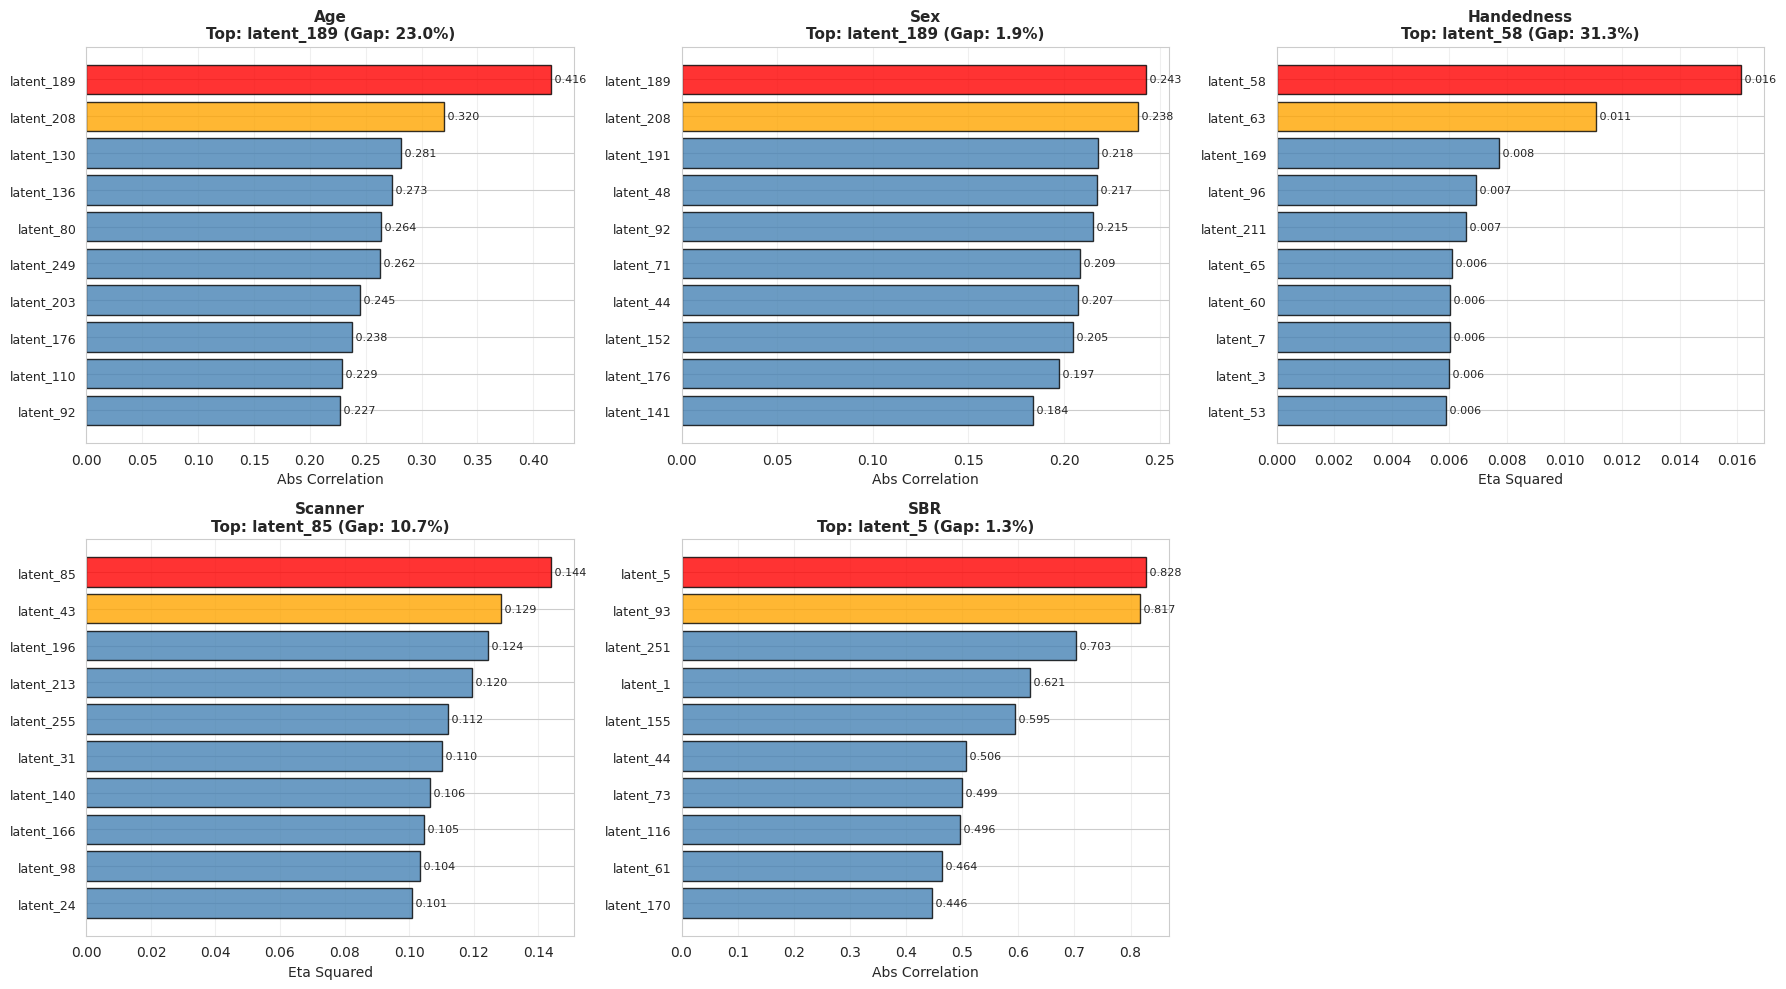

Plot saved to: output/dimension_factor_correlation_top10.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot for each factor
plot_data = [
    ('Age', df_age_corr, age_sep, 'Abs_Correlation'),
    ('Sex', df_sex_corr, sex_sep, 'Abs_Correlation'),
    ('Handedness', df_hand_corr, hand_sep, 'Eta_Squared' if df_hand_corr is not None and 'Eta_Squared' in df_hand_corr.columns else 'Abs_Correlation'),
    ('Scanner', df_scanner_corr, scanner_sep, 'Eta_Squared'),
    ('SBR', df_sbr_corr, sbr_sep, 'Abs_Correlation')
]

for idx, (factor_name, df_corr, sep, metric_col) in enumerate(plot_data):
    if df_corr is None or sep is None:
        axes[idx].text(0.5, 0.5, f'{factor_name}\nNo data available', 
                      ha='center', va='center', fontsize=12)
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
        continue
    
    # Get top 10
    top_10 = df_corr.head(10)
    
    # Create bar plot
    colors = ['red' if i == 0 else 'orange' if i == 1 else 'steelblue' for i in range(len(top_10))]
    bars = axes[idx].barh(range(len(top_10)), top_10[metric_col], color=colors, edgecolor='black', alpha=0.8)
    
    axes[idx].set_yticks(range(len(top_10)))
    axes[idx].set_yticklabels(top_10['Feature'], fontsize=9)
    axes[idx].set_xlabel(metric_col.replace('_', ' '), fontsize=10)
    axes[idx].set_title(f'{factor_name}\nTop: {sep["Top_Feature"]} (Gap: {sep["Gap_Percent"]:.1f}%)', 
                       fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].invert_yaxis()
    
    # Add value labels
    for i, (feat, val) in enumerate(zip(top_10['Feature'], top_10[metric_col])):
        axes[idx].text(val, i, f' {val:.3f}', va='center', fontsize=8)

# Remove unused subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('output/dimension_factor_correlation_top10.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_correlation_top10.png")

### 4.3 Visualization: Separation Gap Comparison

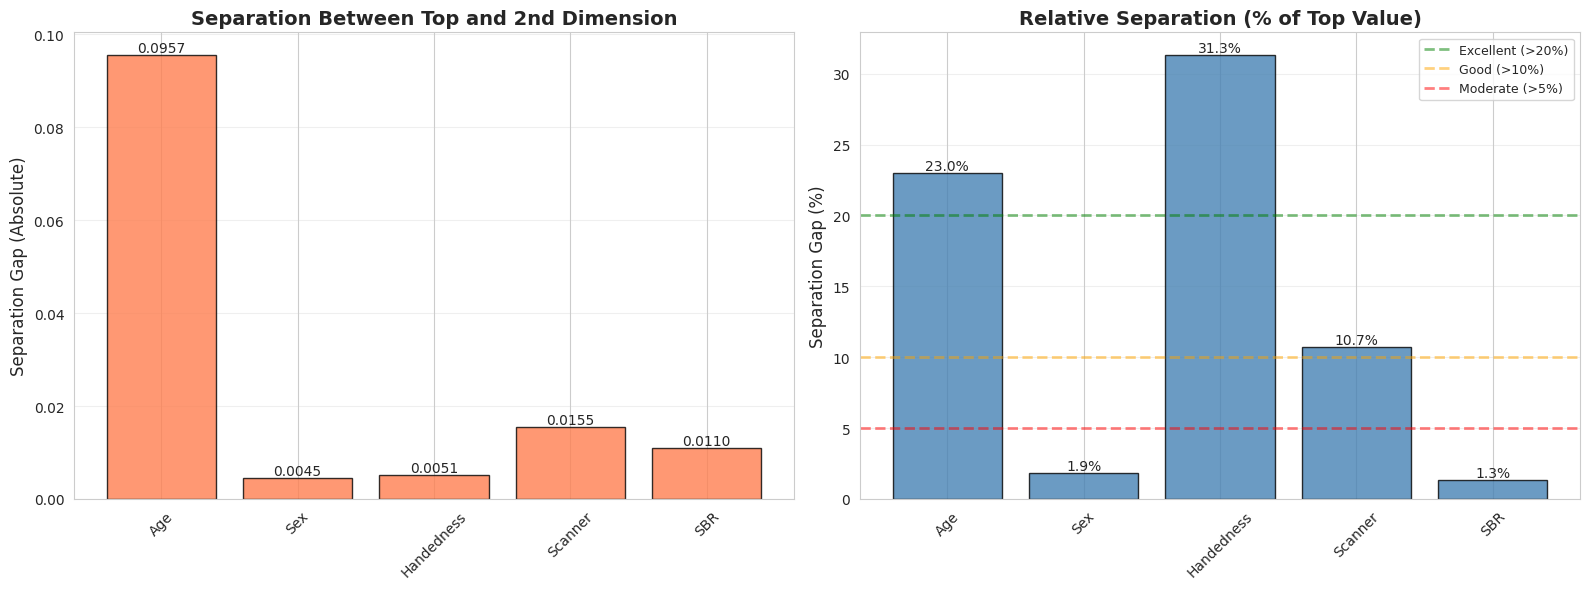

Plot saved to: output/dimension_factor_separation_gaps.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute gap
axes[0].bar(df_summary['Factor'], df_summary['Gap'], color='coral', edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Separation Gap (Absolute)', fontsize=12)
axes[0].set_title('Separation Between Top and 2nd Dimension', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, (factor, gap) in enumerate(zip(df_summary['Factor'], df_summary['Gap'])):
    axes[0].text(i, gap, f'{gap:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 2: Relative gap (percentage)
axes[1].bar(df_summary['Factor'], df_summary['Gap_Percent'], color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Separation Gap (%)', fontsize=12)
axes[1].set_title('Relative Separation (% of Top Value)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for i, (factor, gap_pct) in enumerate(zip(df_summary['Factor'], df_summary['Gap_Percent'])):
    axes[1].text(i, gap_pct, f'{gap_pct:.1f}%', ha='center', va='bottom', fontsize=10)

# Add threshold lines
axes[1].axhline(y=20, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Excellent (>20%)')
axes[1].axhline(y=10, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Good (>10%)')
axes[1].axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Moderate (>5%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('output/dimension_factor_separation_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_separation_gaps.png")

### 4.4 Visualization: Heatmap of Top Dimensions

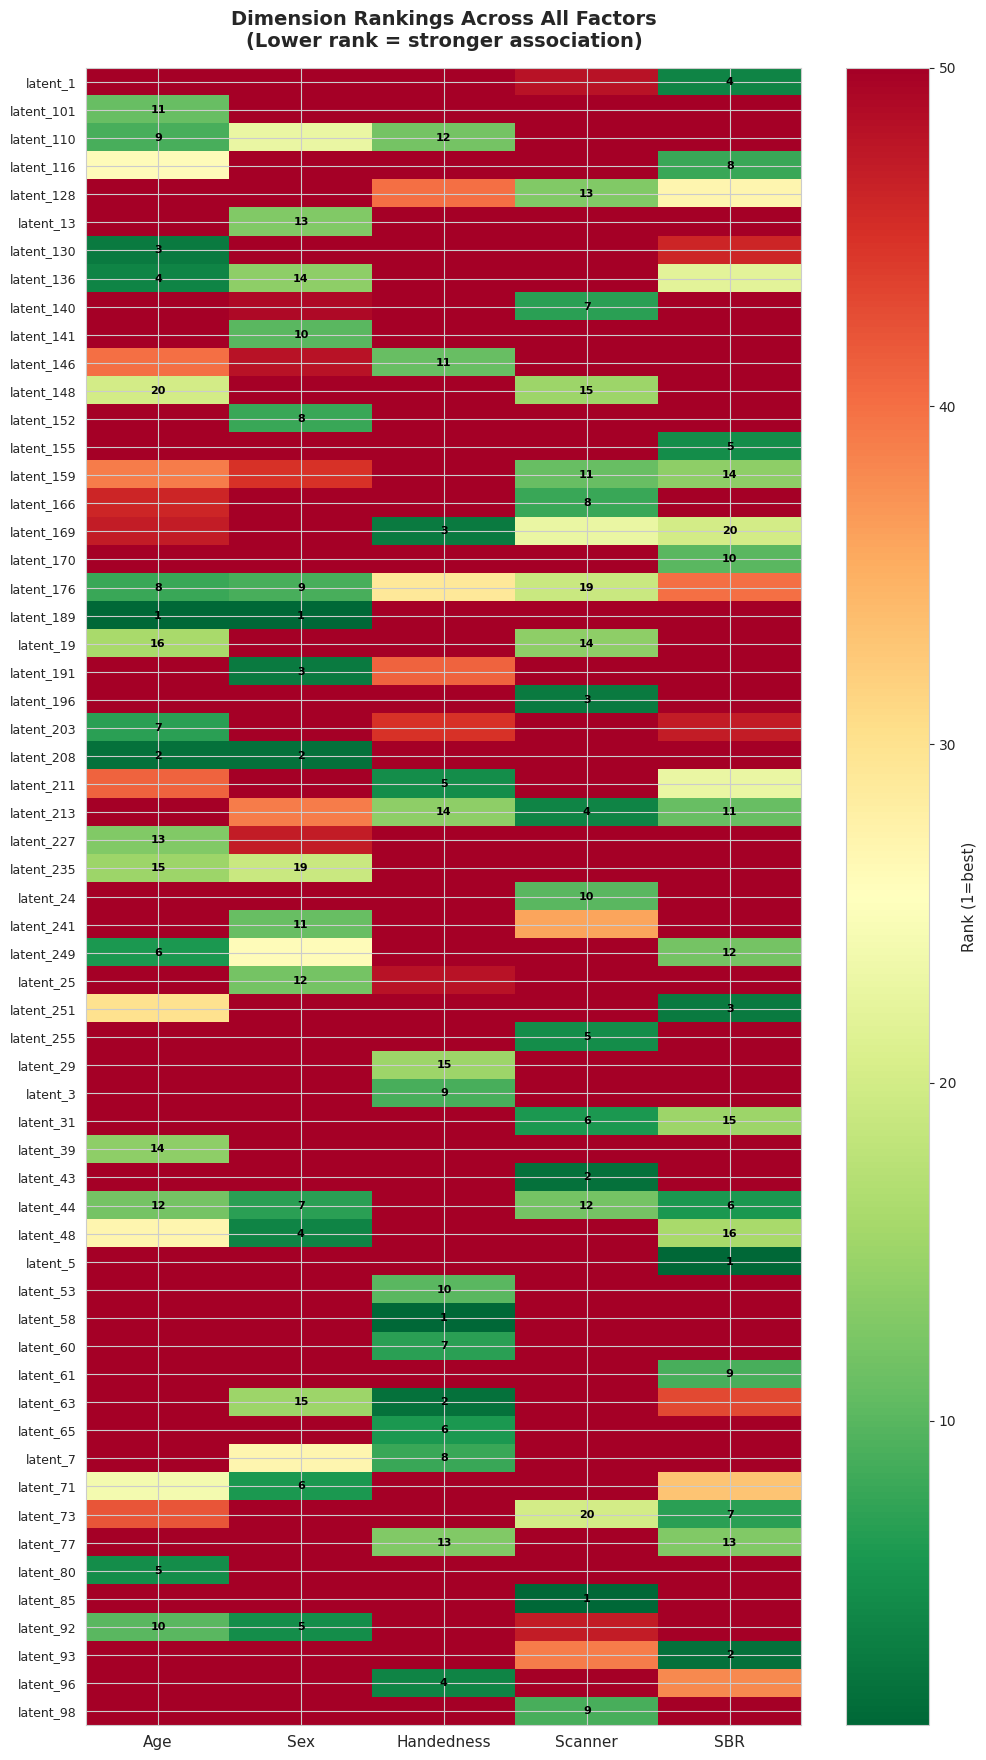

Plot saved to: output/dimension_factor_ranking_heatmap.png


In [18]:
# Create a matrix showing top dimensions for each factor
top_n_display = 15

# Collect all top dimensions
all_top_dims = set()
factor_rankings = {}

for factor_name, df_corr, sep, metric_col in plot_data:
    if df_corr is None:
        continue
    top_dims = df_corr.head(top_n_display)['Feature'].tolist()
    all_top_dims.update(top_dims)
    factor_rankings[factor_name] = {row['Feature']: row['Rank'] for _, row in df_corr.iterrows()}

all_top_dims = sorted(list(all_top_dims))

# Create ranking matrix
ranking_matrix = []
factor_names = [name for name, _, _, _ in plot_data if name in factor_rankings]

for dim in all_top_dims:
    row = []
    for factor_name in factor_names:
        rank = factor_rankings[factor_name].get(dim, 257)  # 257 if not in top rankings
        row.append(rank)
    ranking_matrix.append(row)

ranking_matrix = np.array(ranking_matrix)

# Create heatmap
fig, ax = plt.subplots(figsize=(10, max(8, len(all_top_dims) * 0.3)))

# Use reversed colormap so rank 1 is darkest
im = ax.imshow(ranking_matrix, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=50)

# Set ticks
ax.set_xticks(range(len(factor_names)))
ax.set_xticklabels(factor_names, fontsize=11)
ax.set_yticks(range(len(all_top_dims)))
ax.set_yticklabels(all_top_dims, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Rank (1=best)', fontsize=11)

# Add rank values to cells (only for top 20)
for i in range(len(all_top_dims)):
    for j in range(len(factor_names)):
        rank = ranking_matrix[i, j]
        if rank <= 20:
            text = ax.text(j, i, f'{int(rank)}',
                          ha="center", va="center", color="black", fontsize=8, fontweight='bold')

ax.set_title('Dimension Rankings Across All Factors\n(Lower rank = stronger association)', 
            fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('output/dimension_factor_ranking_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_ranking_heatmap.png")

## Section 5: Save Results

### 5.1 Save Correlation Results

In [19]:
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# Save individual correlation results
df_age_corr.to_csv(output_dir / 'dimension_correlations_age.csv', index=False)
df_sex_corr.to_csv(output_dir / 'dimension_correlations_sex.csv', index=False)
if df_hand_corr is not None:
    df_hand_corr.to_csv(output_dir / 'dimension_correlations_handedness.csv', index=False)
df_scanner_corr.to_csv(output_dir / 'dimension_correlations_scanner.csv', index=False)
df_sbr_corr.to_csv(output_dir / 'dimension_correlations_sbr.csv', index=False)

# Save summary
df_summary.to_csv(output_dir / 'dimension_factor_summary.csv', index=False)

print("Results saved to:")
print(f"  - {output_dir / 'dimension_correlations_age.csv'}")
print(f"  - {output_dir / 'dimension_correlations_sex.csv'}")
if df_hand_corr is not None:
    print(f"  - {output_dir / 'dimension_correlations_handedness.csv'}")
print(f"  - {output_dir / 'dimension_correlations_scanner.csv'}")
print(f"  - {output_dir / 'dimension_correlations_sbr.csv'}")
print(f"  - {output_dir / 'dimension_factor_summary.csv'}")

Results saved to:
  - output/dimension_correlations_age.csv
  - output/dimension_correlations_sex.csv
  - output/dimension_correlations_handedness.csv
  - output/dimension_correlations_scanner.csv
  - output/dimension_correlations_sbr.csv
  - output/dimension_factor_summary.csv


### 5.2 Final Summary

In [20]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

print("\nKey Findings:")
print("-" * 80)

for _, row in df_summary.iterrows():
    quality = "EXCELLENT" if row['Gap_Percent'] > 20 else "GOOD" if row['Gap_Percent'] > 10 else "MODERATE" if row['Gap_Percent'] > 5 else "WEAK"
    
    print(f"\n{row['Factor']}:")
    print(f"  Top Dimension: {row['Top_Dimension']}")
    print(f"  {row['Metric']}: {row['Top_Value']:.4f}")
    print(f"  Separation: {quality} ({row['Gap_Percent']:.1f}% gap from 2nd-best)")
    print(f"  Statistical significance: p={row['P_Value']:.4e}")

print("\n" + "="*80)
print("All results and visualizations saved to output/ directory")
print("="*80)


ANALYSIS COMPLETE

Key Findings:
--------------------------------------------------------------------------------

Age:
  Top Dimension: latent_189
  Pearson r: 0.4159
  Separation: EXCELLENT (23.0% gap from 2nd-best)
  Statistical significance: p=1.3357e-275

Sex:
  Top Dimension: latent_189
  Point-biserial r: 0.2430
  Separation: WEAK (1.9% gap from 2nd-best)
  Statistical significance: p=1.1306e-89

Handedness:
  Top Dimension: latent_58
  Eta²: 0.0161
  Separation: EXCELLENT (31.3% gap from 2nd-best)
  Statistical significance: p=3.9428e-24

Scanner:
  Top Dimension: latent_85
  Eta²: 0.1440
  Separation: GOOD (10.7% gap from 2nd-best)
  Statistical significance: p=7.3128e-211

SBR:
  Top Dimension: latent_5
  Pearson r: 0.8278
  Separation: WEAK (1.3% gap from 2nd-best)
  Statistical significance: p=0.0000e+00

All results and visualizations saved to output/ directory
